# Lecture 3b — Lepton Propagation with **PROPOSAL**

### Neutrino Interactions, Simulation and Event Generation · *N. Kamp*

This is part of a **3-notebook** set following the simulation pipeline:
```
  FLUX  ->  INTERACTION  ->  PROPAGATION  ->  LIGHT + DETECTOR
  [ SIREN tables + injection + weights ]  [ PROPOSAL ]  [ Prometheus ]
     part a  (this set: a=SIREN, b=PROPOSAL, c=Prometheus)
```

**This notebook (part b)** takes the $\tau$ made in 3a and follows its **race between flying and
decaying** — the decay-length distribution, the double-bang resolvability window, and how **PROPOSAL**
samples the real decay point with stochastic energy loss.

In [ ]:
subprocess.run([ 'git', 'clone', 'https://github.com/Harvard-Neutrino/prometheus.git' ], check=True)
subprocess.run([ 'cd', 'prometheus', '&&', 'bash', 'install.sh --with-ppc'], check=True)


Cloning into 'prometheus'...


CompletedProcess(args=['cd', 'prometheus', '&&', 'bash', 'install.sh --with-ppc'], returncode=0)

## Setup

Run this first. On Colab it clones the repo so `helpers` and `data/` exist, then puts `src/` on the
path. **Set `REPO_URL` to your repository.** Every data stage reads a **real** file you generated
with `make_cache.py` (committed to `data/` or hosted); if one is missing, the cell raises a clear
error telling you which `make_cache.py` command to run. There are no synthetic stand-ins.

In [2]:
# === Setup: make the repo's helper code importable (the Colab fix) ===
# Colab's GitHub browser loads ONLY this .ipynb -- the surrounding repo
# (src/helpers.py, data/) is NOT cloned. So we clone it into the runtime here.
import os, sys, subprocess

REPO_URL = 'https://github.com/USER/REPO.git'   # <-- set to your repo
SUBDIR   = 'Lecture3_Simulation'                # folder that holds src/ and data/

if 'google.colab' in sys.modules and not os.path.isdir('REPO'):
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, 'REPO'], check=True)

# Find the folder containing src/helpers.py, whether cloned (Colab) or in-repo (local):
_cands = ['REPO/' + SUBDIR, SUBDIR, '.', '..', '../..']
_base  = next((p for p in _cands if os.path.isdir(os.path.join(p, 'src'))), None)
assert _base, 'Could not find src/ -- check REPO_URL / SUBDIR.'
sys.path.insert(0, os.path.abspath(os.path.join(_base, 'src')))

# install prometheus following documentation
if 'google.colab' in sys.modules:
    subprocess.run([sys.executable, 'git clone https://github.com/Harvard-Neutrino/prometheus.git && cd prometheus && bash install.sh --with-ppc'], check=True)

import numpy as np, matplotlib.pyplot as plt
import helpers as H
print('helpers loaded from:', H.__file__)
for _m in ('siren', 'proposal', 'prometheus'):     # did the installs work?
    print(f'  {_m:11s} importable: {H.have(_m)}')

helpers loaded from: /Users/nickkamp/Documents/Harvard/Outreach/CNP/CNP_Neutrino_Interactions/Lecture3_Simulation/src/helpers.py
  siren       importable: True
  proposal    importable: True
  prometheus  importable: False


> **Running on Colab.** The disk is wiped each session, so re-run Setup every time. The data plotted
> below is always **real**: either produced by the tool live (if installed) or read from a cached
> file you made with `make_cache.py`. SIREN/PROPOSAL/Prometheus are compiled C++; SIREN can install
> from a **prebuilt wheel** (see README), while PROPOSAL/Prometheus are slow to build — so for those
> we read cached output. A missing cache raises a clear error (it never invents data).

## 1. Propagation — the tau's race between flying and decaying

A $\nu_\tau$ CC event makes a $\tau$. Whether you see a **double bang** depends on the tau
**decay length** $L = \gamma c\tau \approx 50\,\mathrm{m} \times (E_\tau/\mathrm{PeV})$ being long enough to
separate the two cascades, but short enough to decay inside the detector. **PROPOSAL** handles the
charged-lepton propagation and stochastic losses (Lecture 2). Below we read **real PROPOSAL output**
(decay lengths, generated by `make_cache.py --tau`) and turn it into a *double-bang efficiency* —
compared against the naive $\gamma c\tau$ expectation to see what the energy losses actually do.

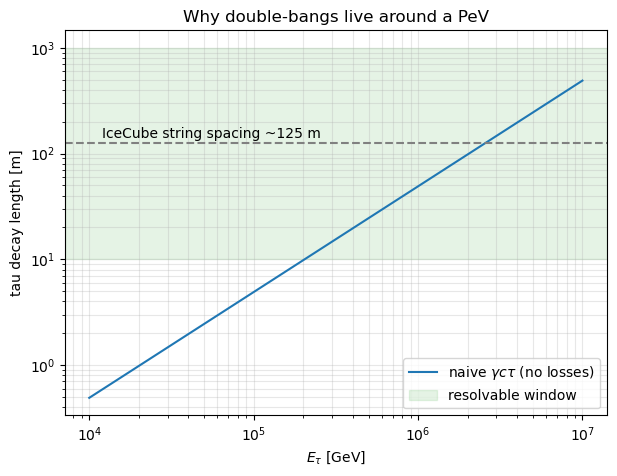

In [2]:
# Reference curve: naive mean decay length L = (E/m_tau)*c*tau (NO energy loss).
E_tau = np.logspace(4, 7, 100)                 # 10 TeV - 10 PeV
L_mean = H.tau_mean_decay_length_m(E_tau)

plt.figure(figsize=(7,5))
plt.loglog(E_tau, L_mean, label=r'naive $\gamma c\tau$ (no losses)')
plt.axhspan(10, 1000, alpha=.12, color='C2', label='resolvable window')
plt.axhline(125, ls='--', color='grey'); plt.text(1.2e4, 140, 'IceCube string spacing ~125 m')
plt.xlabel(r'$E_\tau$ [GeV]'); plt.ylabel('tau decay length [m]')
plt.legend(); plt.title('Why double-bangs live around a PeV'); plt.grid(alpha=.3, which='both'); plt.show()

In [3]:
# ---- (illustrative) sampling the REAL decay point with PROPOSAL ----
# PROPOSAL also applies stochastic energy loss before the tau decays. Watch its
# units: energy in MeV, length in cm. It compiles from source, so not run live.
if H.have('proposal'):
    import proposal as pp
    prop = pp.Propagator(
        particle_def=pp.particle.TauMinusDef(),
        path_to_config_file='config_ice.json')      # PROPOSAL ships example configs
    state = pp.particle.ParticleState()
    state.position = pp.Cartesian3D(0, 0, 0)         # cm
    state.direction = pp.Cartesian3D(0, 0, 1)
    state.energy = 1e9                               # MeV  (= 1 PeV)
    track = prop.propagate(state, max_distance=1e5)  # cm
    print(f'PROPOSAL tau decayed after {track.final_state().propagated_distance/100:.1f} m')
else:
    print('proposal not installed -- we read the cached PROPOSAL decays below.')

: 

In [ ]:
# ---- decay-length distribution + double-bang efficiency, from REAL PROPOSAL output ----
tau = H.load_tau_decays('tau_decays_proposal.parquet')   # columns: energy_gev, decay_length_m
E = tau['energy_gev'].to_numpy(); L = tau['decay_length_m'].to_numpy()
print(f'loaded {len(tau)} PROPOSAL tau decays')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
# left: decay-length distribution in a few energy bands
for lo, hi, lbl in [(0.5e5,2e5,'~0.1 PeV'), (0.5e6,2e6,'~1 PeV'), (0.5e7,2e7,'~10 PeV')]:
    sel = (E >= lo) & (E < hi)
    if sel.sum():
        ax[0].hist(L[sel], bins=np.logspace(-1,4,60), histtype='step', density=True, label=lbl)
ax[0].axvspan(10, 1000, alpha=.12, color='C2')
ax[0].set_xscale('log'); ax[0].set_xlabel('decay length [m]'); ax[0].set_ylabel('pdf')
ax[0].legend(title=r'$E_\tau$'); ax[0].set_title('PROPOSAL tau decay lengths')

# right: REAL efficiency = fraction with decay length in the window, per energy bin
def eff_vs_E(dmin, dmax, nb=18):
    bins = np.logspace(4, 7.5, nb+1); cen = np.sqrt(bins[1:]*bins[:-1])
    num,_ = np.histogram(E[(L>=dmin)&(L<=dmax)], bins=bins); den,_ = np.histogram(E, bins=bins)
    return cen, np.divide(num, den, out=np.full(nb, np.nan), where=den>0)
for (dmin, dmax, c) in [(10,1000,'C0'), (30,1000,'C1')]:
    cen, e = eff_vs_E(dmin, dmax)
    ax[1].semilogx(cen, e, 'o-', color=c, label=f'{dmin}-{dmax} m (PROPOSAL)')
# labelled reference: naive exponential from gamma*c*tau, NO energy loss
Eg = np.logspace(4, 7.5, 200); Lm = H.tau_mean_decay_length_m(Eg)
ax[1].semilogx(Eg, np.exp(-10/Lm) - np.exp(-1000/Lm), 'k--', lw=1,
               label=r'naive $\gamma c\tau$ (no losses)')
ax[1].set_xlabel(r'$E_\tau$ [GeV]'); ax[1].set_ylabel('double-bang fraction')
ax[1].legend(); ax[1].set_title('Resolvable double-bang efficiency vs energy')
plt.tight_layout(); plt.show()

> **🔧 Try it.** The right panel is a *resolvability* curve: too low in energy and the tau decays
> within metres (one merged cascade); too high and it usually exits before decaying (a track). Compare
> the **PROPOSAL points** to the dashed **naive $\gamma c\tau$** curve — they diverge at high energy
> because PROPOSAL's stochastic losses bleed off tau energy before it decays. Raise the window's lower
> edge 10 m → 30 m (worse vertex resolution): what happens to the peak height and where it peaks?

## Wrap-up

**References:** Prometheus (arXiv:2304.14526), SIREN / LeptonInjector (arXiv:2012.10449),
PROPOSAL (Comput.Phys.Commun. 2019), nuSQuIDS (arXiv:2112.13804), SIREN flux tables
(Zenodo 20129082), Formaggio & Zeller (Rev.Mod.Phys. 2012).

**Go further:**
- Regenerate with `make_cache.py --tau` at higher statistics, or swap `TauMinusDef`->`MuMinusDef` to study muon range.
- Use the cached decay lengths to place the second cascade, then view it in **3c (Prometheus)**.
- Weight the efficiency curve by the 3a tau spectrum for a physical double-bang rate.